# 3.1. Predictive Modelling

The purpose of this notebook is to determine which among the SVC, Tree classifier, and logistic regression yield the highest test score given a chosen metric. 

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**TASK 1.** Load the data and create the features matrix and target matrix

In [2]:
# Load data
from pathlib import Path

file = Path.cwd().parent / 'data/processed/api-launch-data-table-class.csv'
data = pd.read_csv(file)
data.dtypes

launch_designator        str
booster_version          str
orbit                    str
launch_site              str
flights                int64
reused                  bool
landing_pad              str
block                    str
serial                   str
longitude            float64
latitude             float64
reused_count           int64
outcome                  str
OrbPay               float64
launch_date              str
gridfins                bool
legs                    bool
class                  int64
dtype: object

In [3]:
cat_cols = ['orbit', 'launch_site', 'reused', 'block', 'gridfins', 'legs']
con_cols = ['OrbPay', 'flights', 'reused_count']
target_col = 'class'

cats = [data[col].unique() for col in cat_cols]

X = pd.concat([data[cat_cols],data[con_cols]], axis=1).to_numpy()
y = data[target_col].to_numpy()
X.shape, y.shape

((95, 9), (95,))

**TASK 2.** Instantiate components of the preprocessor -- `OneHotEncoder` and `StandardScaler`

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

build_features = ColumnTransformer([
    ('encode', OneHotEncoder(sparse_output=False, dtype=int, categories=cats), list(range(0,6))),
    ('scale', StandardScaler(), list(range(6,9)))
])

**TASK 3.** Split the data into training and test sets with `test_size = 0.2` and `random_state = 2`.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [6]:
X_train.shape, X_test.shape

((76, 9), (19, 9))

**TASK 4. (Logistic Regression)** Create a pipeline with `build_features` as the preprocessor, and Logistic Regression as the estimator. Do a grid search with the pipeline, considering `C`, `penalty`, and `solver` in the hyperparameter grid.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

logreg_param_grid = {
    'estimator__C': [0.01, 0.1, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
    'estimator__l1_ratio': [0],
    'estimator__solver': ['lbfgs']
}
logreg = Pipeline([('transformer', build_features),
                   ('estimator', LogisticRegression())
                  ])

logreg_gridcv = GridSearchCV(logreg, logreg_param_grid)
logreg_gridcv.fit(X_train, y_train)

print("best parameters: {}".format(logreg_gridcv.best_params_))
print("accuracy: {}".format(logreg_gridcv.best_score_))

best parameters: {'estimator__C': 1.0, 'estimator__l1_ratio': 0, 'estimator__solver': 'lbfgs'}
accuracy: 0.9216666666666666


**TASK 5. (Logistic Regression Evaluation)** Calculate the score of the logistic regression pipeline on the test set and plot the confusion matrix.

In [8]:
logreg_score = logreg_gridcv.score(X_test, y_test)
print('Logistic Regression Score: {}'.format(logreg_score))

Logistic Regression Score: 0.8421052631578947


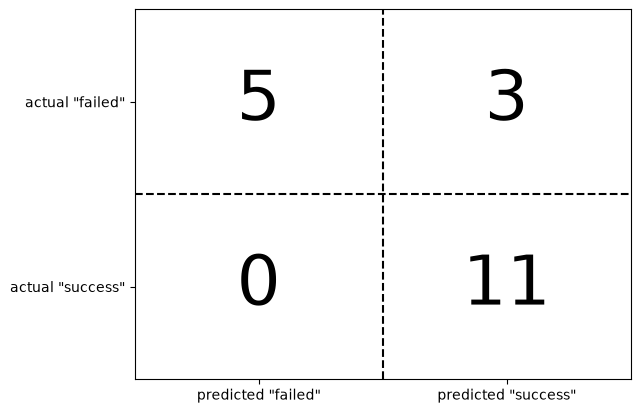

In [9]:
from sklearn.metrics import confusion_matrix

def binary_confusion_plot(binary_confusion_matrix, positive_class, negative_class, ax=None):
    if ax is None:
        ax = plt.gca()
    
    for i in range(binary_confusion_matrix.shape[0]):
        for j in range(binary_confusion_matrix.shape[1]):
            ax.text(j, i, '{}'.format(binary_confusion_matrix[::-1][i,j]),
                   ha='center', va='center', fontsize=50)
    
    ax.vlines(x=0.5, ymin=-0.5, ymax=1.5, linestyle='--', colors='k')
    ax.plot([-0.5,1.5], [0.5,0.5], linestyle='--', c='k')
    ax.set_xticks([0,1], labels=[f'predicted "{negative_class}"', f'predicted "{positive_class}"'])
    ax.set_xlim(-0.5,1.5)
    ax.set_yticks([0,1], labels=[f'actual "{positive_class}"', f'actual "{negative_class}"'])
    ax.set_ylim(-0.5,1.5)

logreg_predict = logreg_gridcv.predict(X_test)
logreg_confusion = confusion_matrix(y_test, logreg_predict)
binary_confusion_plot(logreg_confusion, 'success', 'failed')

**Conclusion.** what...

**TASK 6. (Support Vector Classifier)** Create a pipeline with `build_features` as the preprocessor, and Support Vector Classifoer as the estimator. Do a grid search with the pipeline, considering `C`, `gamma`, and `kernel` in the hyperparameter grid.

In [10]:
from sklearn.svm import SVC

svc_param_grid = [
    {
        'estimator__kernel':['poly', 'rbf', 'sigmoid'],
        'estimator__C': np.logspace(-3, 3, 5),
        'estimator__gamma':np.logspace(-3, 3, 5)
    },
    {
        'estimator__kernel':['linear',],
        'estimator__C': np.logspace(-3, 3, 5)
    }
]

svc = Pipeline([
    ('transformer', build_features),
    ('estimator', SVC())
])

svc_gridcv = GridSearchCV(svc, svc_param_grid)
svc_gridcv.fit(X_train,y_train)

print("best parameters: {}".format(svc_gridcv.best_params_))
print("accuracy: {}".format(svc_gridcv.best_score_))

best parameters: {'estimator__C': np.float64(1000.0), 'estimator__kernel': 'linear'}
accuracy: 0.9341666666666667


In [11]:
def heat_map_2D(grid_cv_results, param_grid, param_1, param_2, ax=None):
    if ax is None:
        ax = plt.gca()

    #Get mean test score and reshape results
    shape_1 = len(param_grid[param_1])
    shape_2 = len(param_grid[param_2])
    results = grid_cv_results['mean_test_score'].to_numpy().reshape(shape_1,shape_2)[::-1,::]

    im = ax.imshow(results)
    
    ax.set_xticks(range(shape_1), labels=['{:.3f}'.format(p) for p in param_grid[param_1]])
    ax.set_yticks(range(shape_2), labels=['{:.3f}'.format(p) for p in param_grid[param_2][::-1]])
    
    for i in range(shape_1):
        for j in range(shape_2):
            text = ax.text(j, i, '{:.3f}'.format(results[i,j]),
                          ha='center', va='center', color='w')
    
    ax.set_title('Heat map of mean cross-validation score')
    ax.set_xlabel(param_1)
    ax.set_ylabel(param_2)
    plt.colorbar(im)

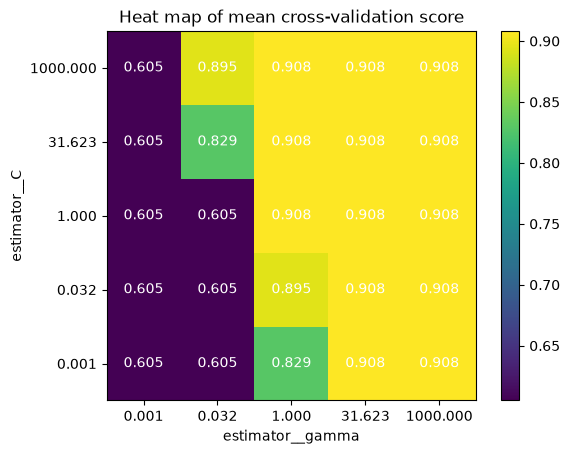

In [12]:
df_grid = pd.DataFrame(svc_gridcv.cv_results_)
grid_cv_results = df_grid[df_grid['param_estimator__kernel']=='poly']
param_1 = 'estimator__gamma'
param_2 = 'estimator__C'

heat_map_2D(grid_cv_results, svc_param_grid[0], param_1, param_2)

**TASK 7. (Support Vector Classifier Evaluation)** Evaluate the results of the SVC grid. Determine the test score and plot the confusion matrix.

In [13]:
svc_score = svc_gridcv.score(X_test,y_test)
svc_pred = svc_gridcv.best_estimator_.predict(X_test)
svc_confusion = confusion_matrix(y_test, svc_pred)

print('SVC Score: {:.3f}'.format(svc_score))

SVC Score: 0.895


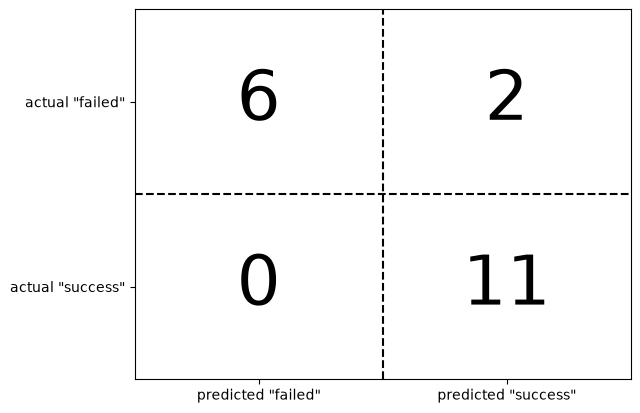

In [14]:
binary_confusion_plot(svc_confusion, 'success', 'failed')

**TASK 8. (Decision Tree Classifier)** Create a pipeline with `build_features` as the preprocessor, and Decision Tree Classifier as the estimator. Do a grid search with the pipeline, considering `criterion`, `splitter`, `max_depth`, `max_features`, `min_samples_leaf`, and `min_samples_split` in the hyperparameter grid.

In [15]:
from sklearn.tree import DecisionTreeClassifier

tree_param_grid = {'estimator__criterion': ['gini', 'entropy'],
     'estimator__splitter': ['best', 'random'],
     'estimator__max_depth': [2*n for n in range(1,10)],
     'estimator__max_features': ['log2', 'sqrt'],
     'estimator__min_samples_leaf': [1, 2, 4],
     'estimator__min_samples_split': [2, 5, 10]}

tree = Pipeline([
    ('transformer', build_features),
    ('estimator', DecisionTreeClassifier())
])

tree_gridcv = GridSearchCV(tree, tree_param_grid)
tree_gridcv.fit(X_train, y_train)

print("best parameters: {}".format(tree_gridcv.best_params_))
print("accuracy: {}".format(tree_gridcv.best_score_))

best parameters: {'estimator__criterion': 'entropy', 'estimator__max_depth': 8, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 10, 'estimator__splitter': 'random'}
accuracy: 0.9216666666666666


**TASK 9. (Decision Tree Classifier Evaluation)** Evaluate the grid search with the decision tree classifier. Determine the test score and plot the confusion matrix.

In [16]:
tree_score = tree_gridcv.score(X_test, y_test)
print('Decision Tree Classifier Score: {:.3f}'.format(tree_score))

Decision Tree Classifier Score: 0.789


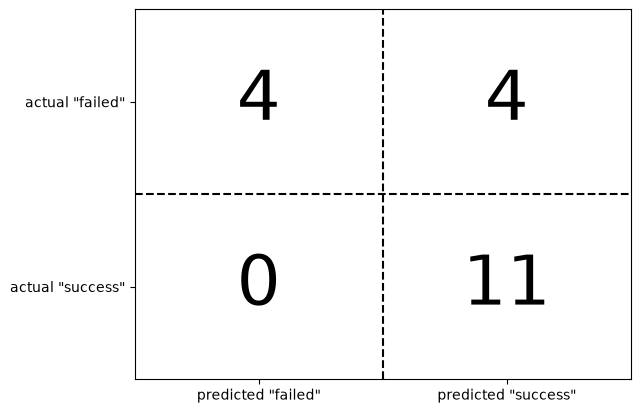

In [17]:
tree_pred = tree_gridcv.predict(X_test)
tree_confusion = confusion_matrix(y_test, tree_pred)

binary_confusion_plot(tree_confusion, 'success', 'failed')

**TASK 10. (K Neighbors Classifier)** Create a pipeline with `build_features` as the preprocessor, and K Neighbors Classifier as the estimator. Do a grid search with the pipeline, considering `n_neighbors`, `algorithm`, and `p` in the hyperparameter grid.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_param_grid = {'estimator__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'estimator__algorithm': ['ball_tree', 'kd_tree', 'brute'],
              'estimator__p': [1,2]}

knn = Pipeline([
    ('transformer', build_features),
    ('estimator', KNeighborsClassifier())
])

knn_gridcv = GridSearchCV(knn, knn_param_grid)
knn_gridcv.fit(X_train, y_train)

print('best parameters: {}'.format(knn_gridcv.best_params_))
print('best score: {}'.format(knn_gridcv.best_score_))

best parameters: {'estimator__algorithm': 'ball_tree', 'estimator__n_neighbors': 10, 'estimator__p': 1}
best score: 0.8958333333333333


**TASK 11. (K Neighbors Classifier Evaluation)** Evaluate the grid search with K-Neighbors Classifier. Determine the test score and plot the confusion matrix.

In [19]:
knn_score = knn_gridcv.score(X_test, y_test)
print('K Neighbors Classifier Score: {:.3f}'.format(knn_score))

K Neighbors Classifier Score: 0.737


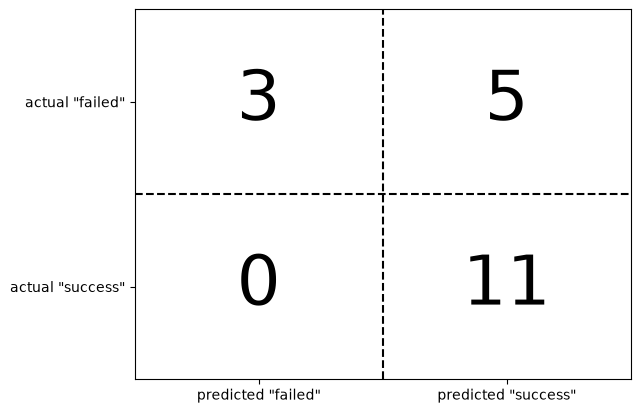

In [20]:
knn_pred = knn_gridcv.predict(X_test)
knn_confusion = confusion_matrix(y_test, knn_pred)

binary_confusion_plot(knn_confusion, 'success', 'failed')

**TASK 12** Determine which method is the best

In [21]:
models_results = {
    'classifiers': ['Logistic Regression', 'Support Vector Classifier', 'Decision Tree Classifier', 'K Neighbors Classifier'],
    'best_cross_val_score': [logreg_gridcv.best_score_, svc_gridcv.best_score_, tree_gridcv.best_score_, knn_gridcv.best_score_],
    'test_score': [logreg_score, svc_score, tree_score, knn_score]
}

models_df = pd.DataFrame(models_results)
print(models_df)

                 classifiers  best_cross_val_score  test_score
0        Logistic Regression              0.921667    0.842105
1  Support Vector Classifier              0.934167    0.894737
2   Decision Tree Classifier              0.921667    0.789474
3     K Neighbors Classifier              0.895833    0.736842


The best method to use is the Support Vector Classifier, getting the highest test score of 89%.